<a href="https://colab.research.google.com/github/shabrii-naa/Sentiment-Bank-Jago-and-Revamp-Validation/blob/main/Sentiment_Bank_Jago_%2B_revamp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install google-play-scrapper

# **1. IMPORT**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import datetime as dt
import re
import string
import nltk
nltk.download("punkt_tab")
nltk.download("stopwords")
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from wordcloud import WordCloud

#import pustaka pelabelan data
import csv
import requests
from io import StringIO

#import pustaka untuk ekstraksi fitur teks
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

#Import Library
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
dataset_path = "bjago_scraping.csv"
bjago_df = pd.read_csv(dataset_path, on_bad_lines='skip', delimiter=',')

In [ ]:
bjago_df.head()

,userName,score,at,content
0,Pengguna Google,1,2025-12-06 23:35:06,Jika tidak bisa memberikan pelayanan atau fitu...
1,Pengguna Google,3,2025-12-07 14:23:54,"fitur pinjaman saya tidak bisa di gunakan,untu..."
2,Pengguna Google,3,2025-12-02 06:03:20,"semuanya bagus, cuma belom bisa Nampilin Qris ..."
3,Pengguna Google,1,2025-12-05 03:42:12,"bahaya, jangan taruh uang di jago, akun saya a..."
4,Pengguna Google,2,2025-12-05 00:14:22,"Tidak rekomendasi banget, uang masuk mudah. ke..."


In [ ]:
bjago_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   userName  50000 non-null  object
 1   score     50000 non-null  int64 
 2   at        50000 non-null  object
 3   content   50000 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.5+ MB


In [ ]:
print(f"Total Dataset {bjago_df.shape[0]} rows and {bjago_df.shape[1]} columns")

Total Dataset 50000 rows and 4 columns


In [ ]:
print("Jumlah duplikasi:", bjago_df.duplicated().sum())

Jumlah duplikasi: 0


# **2. Preprocessing Text**

In [ ]:
def cleaning_text(text):
  "Membersikah teks dengan hapus mention, link, angka, dan tanda baca"
  text = re.sub(r'@[A-Za-z0-9_]+', '', text) #Hapus mention
  text = re.sub(r'#', '', text) #Hapus hastag
  text = re.sub(r'RT :', '', text) #Hapus RT
  text = re.sub(r'https?:\/\/\S+', '', text) #Hapus link
  text = re.sub(r'\d+', '', text) #Hapus angka
  text = text.translate(str.maketrans('', '', string.punctuation)) #Hapus tanda baca
  return text

In [ ]:
def casefolding_text(text):
  return text.lower()
def tokenizing_text(text):
  return word_tokenize(text)
def stemming_text(text):
  stemmer = factory.create_stemmer()
  return ''.join([stemmer.stem(word) for word in text.split()])
def to_sentence(words):
  return ' '.join(words)

In [ ]:
bjago_df['clean_text'] = bjago_df['content'].apply(cleaning_text)

In [ ]:
def filtering_text(text):
  NEGATIONS = {'gak','gk','ga','nggak','enggak','tidak','tak','bukan','belum','kurang'}
  ##menghapus kata-kata yang tidak penting
  stop_words = set(stopwords.words('indonesian') + stopwords.words('english'))
  additional_stopwords = ['iya', 'yaa', 'gak', 'nya', 'na', 'sih', 'ku', 'di', 'gaa', 'loh', 'kah', 'woi', 'woii', 'bang','woy', 'yg','aja','nih','deh']
  stop_words.update(additional_stopwords)
  stop_words = stop_words - NEGATIONS
  return [word for word in text if word not in stop_words]

In [ ]:
new_bjago_df = bjago_df.copy()
new_bjago_df['text_clean'] = new_bjago_df['content'].apply(cleaning_text)
new_bjago_df['text_casefolding']= new_bjago_df['text_clean'].apply(casefolding_text)
new_bjago_df['text_tokenizing'] = new_bjago_df['text_casefolding'].apply(tokenizing_text)
new_bjago_df['text_filtering'] = new_bjago_df['text_tokenizing'].apply(filtering_text)
new_bjago_df['text_final'] = new_bjago_df['text_filtering'].apply(to_sentence)

# **3. Pelabelan Dataset**

In [ ]:
# Fungsi untuk memuat data lexicon positif dari GitHub
def load_lexicon(url):
    lexicon = dict()
    response = requests.get(url)  # Mengirim permintaan HTTP untuk mendapatkan file CSV
    if response.status_code == 200:
        # Jika permintaan berhasil, membaca CSV
        reader = csv.reader(StringIO(response.text), delimiter=',')
        for row in reader:
            lexicon[row[0]] = int(row[1])  # Menambahkan kata dan skornya ke dalam kamus
    else:
        print(f"Failed to fetch lexicon data from {url}")
    return lexicon

# Memuat lexicon positif
lexicon_positive_url = 'https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv'
lexicon_positive = load_lexicon(lexicon_positive_url)

# Memuat lexicon negatif
lexicon_negative_url = 'https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv'
lexicon_negative = load_lexicon(lexicon_negative_url)

# Menampilkan beberapa contoh data lexicon positif dan negatif
print("Contoh kata positif:", list(lexicon_positive.items())[:5])  # Menampilkan 5 kata pertama
print("Contoh kata negatif:", list(lexicon_negative.items())[:5])  # Menampilkan 5 kata pertama

Contoh kata positif: [('hai', 3), ('merekam', 2), ('ekstensif', 3), ('paripurna', 1), ('detail', 2)]
Contoh kata negatif: [('putus tali gantung', -2), ('gelebah', -2), ('gobar hati', -2), ('tersentuh (perasaan)', -1), ('isak', -5)]


In [ ]:
def sentiment_analysis_lexicon_indonesia(text):
    """
    Menganalisis sentimen teks berdasarkan lexicon positif dan negatif
    Args:
    - text: List kata-kata dari teks yang akan dianalisis

    Returns:
    - score: Skor sentimen dari teks
    - polarity: Polaritas sentimen, 'positive', 'negative', atau 'neutral'
    """
    score = 0  # Inisialisasi skor sentimen ke 0

    # Mengecek kata-kata positif dalam teks dan menambahkan skor
    for word in text:
        if word in lexicon_positive:
            score += lexicon_positive[word]

    # Mengecek kata-kata negatif dalam teks dan mengurangi skor
    for word in text:
        if word in lexicon_negative:
            score += lexicon_negative[word]

    # Menentukan polaritas berdasarkan skor
    if score > 0:
        polarity = 'positive'
    elif score < 0:
        polarity = 'negative'
    else:
        polarity = 'neutral'  # Jika skor sama dengan 0, berarti netral

    return score, polarity

In [ ]:
results = new_bjago_df['text_filtering'].apply(sentiment_analysis_lexicon_indonesia)

results = list(zip(*results))

new_bjago_df['polarity_score'] = results[0]
new_bjago_df['polarity'] = results[1]

print(new_bjago_df['polarity'].value_counts())

polarity
positive    23587
negative    18626
neutral      7787
Name: count, dtype: int64


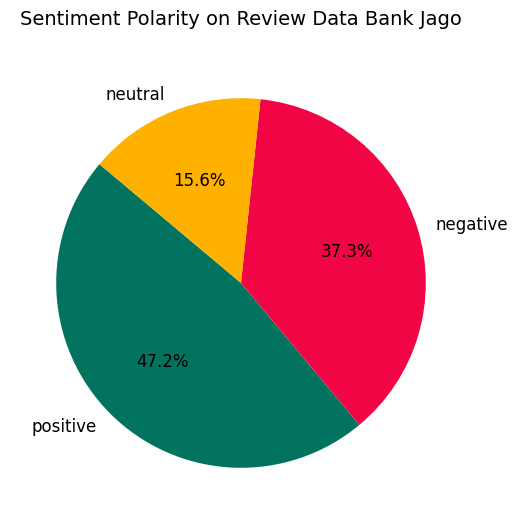

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
sentiment_counts = new_bjago_df['polarity'].value_counts()
sizes = sentiment_counts.values
labels = sentiment_counts.index
explode = [0.1 if i == sentiment_counts.idxmax() else 0 for i in labels]
colors = ['#02735E','#F20544','#FFB100']
ax.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=colors, textprops={'fontsize': 12}, startangle=140
)
ax.set_title('Sentiment Polarity on Review Data Bank Jago', fontsize=14, pad=20)
plt.show()

/tmp/ipython-input-4057375302.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=new_bjago_df['polarity'].value_counts().index,


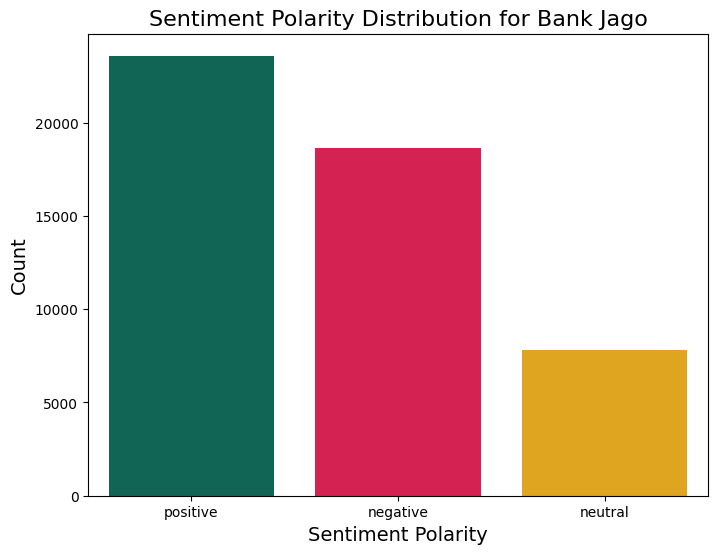

In [ ]:
# Visualisasi Data dengan Bar Chart
plt.figure(figsize=(8, 6))
colors = ['#02735E','#F20544','#FFB100']
sns.barplot(x=new_bjago_df['polarity'].value_counts().index,
            y=new_bjago_df['polarity'].value_counts().values,
            palette=colors)
plt.xlabel("Sentiment Polarity", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Sentiment Polarity Distribution for Bank Jago", fontsize=16)
plt.show()

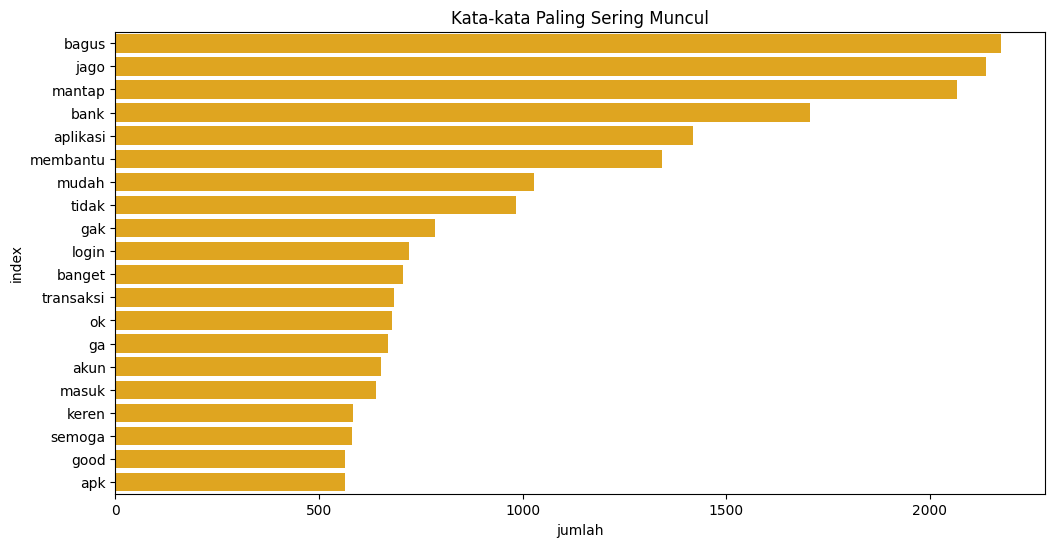

In [ ]:
# Visualisasikan kata-kata yang paling sering muncul menggunakan TF-IDF
plt.figure(figsize=(12, 6))
vectorizer = TfidfVectorizer()  # Membuat objek vectorizer untuk menghitung TF-IDF
X = vectorizer.fit_transform(new_bjago_df['text_final'])  # Menggunakan 'text_final'
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())  # Konversi matriks ke dalam DataFrame
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')  # Menjumlahkan nilai TF-IDF per kata
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)  # Urutkan berdasarkan frekuensi tertinggi
sns.barplot(x='jumlah', y='index', data=tfidf_df, color='#FFB100') # Plot bar chart untuk 20 kata teratas
plt.title('Kata-kata Paling Sering Muncul')
plt.show()

## Data Splitting dan ekstraksi Fitur

In [ ]:
# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = new_bjago_df['text_final']
y = new_bjago_df['polarity']

## **A. Ekstraksi Fitur TF-IDF**

In [ ]:
# Ekstraksi fitur dengan TF-IDF + N-Gram (Unigram dan Bigram)
tfidf = TfidfVectorizer(max_features=10000, min_df=17, max_df=0.8,
ngram_range=(1, 3))
X_tfidf = tfidf.fit_transform(X)
# Konversi hasil ekstraksi fitur menjadi dataframe
features_df_tfidf = pd.DataFrame(X_tfidf.toarray(),
columns=tfidf.get_feature_names_out())
# Bagi data menjadi data latih dan data uji untuk TF-IDF
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
X_tfidf, y, test_size=0.2, random_state=42
)
# Tampilkan dimensi fitur hasil ekstraksi
print("Dimensi fitur TF-IDF:")
print("X_train_tfidf:", X_train_tfidf.shape)
print("X_test_tfidf:", X_test_tfidf.shape)

Dimensi fitur TF-IDF:
X_train_tfidf: (40000, 10393)
X_test_tfidf: (10000, 10393)


# B. Feature Extraction(BoW)

In [ ]:
# B. Feature Extraction(BoW)

# Ekstraksi fitur dengan Bag of Words (BoW) + N-Gram (Unigram dan Bigram)
bow_vectorizer = CountVectorizer(max_features=25000, stop_words='english',
ngram_range=(2, 3))

# Re-assign X to ensure it's the text data (Series of strings)
X = new_bjago_df['text_final']
y = new_bjago_df['polarity']

X_bow = bow_vectorizer.fit_transform(X)
# Konversi hasil ekstraksi fitur menjadi dataframe
features_df_bow = pd.DataFrame(X_bow.toarray(),
columns=bow_vectorizer.get_feature_names_out())
# Bagi data menjadi data latih dan data uji untuk BoW
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
X_bow, y, test_size=0.2, random_state=42
)
# Tampilkan dimensi fitur hasil ekstraksi
print("\nDimensi fitur Bag of Words (BoW):")
print("X_train_bow:", X_train_bow.shape)
print("X_test_bow:", X_test_bow.shape)


Dimensi fitur Bag of Words (BoW):
X_train_bow: (40000, 5000)
X_test_bow: (10000, 5000)


# **MODELLING**

**A. SVM dengan TF-IDF, Pembagian Data 80/20 (Skema 1)**

In [ ]:
# Membuat objek model Support Vector Machine (SVM)
svm = SVC(kernel='linear', C=1)  # Kernel linear dengan C=1

# Melatih model SVM pada data pelatihan (menggunakan fitur TF-IDF)
svm.fit(X_train_tfidf, y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_svm = svm.predict(X_train_tfidf)   # Prediksi pada data latih
y_pred_test_svm = svm.predict(X_test_tfidf)     # Prediksi pada data uji

# Evaluasi akurasi model SVM
accuracy_train_svm = accuracy_score(y_train, y_pred_train_svm)  # Akurasi pada data latih
accuracy_test_svm = accuracy_score(y_test, y_pred_test_svm)      # Akurasi pada data uji

# Menampilkan akurasi untuk model SVM
print('SVM - accuracy_train:', accuracy_train_svm)
print('SVM - accuracy_test:', accuracy_test_svm)
print("\nTF-IDF SVM - Macro F1 (test):", f1_score(y_test, y_pred_test_svm, average="macro"))
print("\nTF-IDF SVM - Classification Report (test):")
print(classification_report(y_test, y_pred_test_svm, digits=4))

print("TF-IDF SVM - Confusion Matrix (test):")
print(confusion_matrix(y_test, y_pred_test_svm))

SVM - accuracy_train: 0.738125
SVM - accuracy_test: 0.6681

TF-IDF SVM - Macro F1 (test): 0.5031169786331265

TF-IDF SVM - Classification Report (test):
              precision    recall  f1-score   support

    negative     0.7986    0.6212    0.6988      3722
     neutral     0.4375    0.0415    0.0759      1517
    positive     0.6186    0.9044    0.7347      4761

    accuracy                         0.6681     10000
   macro avg     0.6182    0.5224    0.5031     10000
weighted avg     0.6581    0.6681    0.6214     10000

TF-IDF SVM - Confusion Matrix (test):
[[2312   31 1379]
 [ 178   63 1276]
 [ 405   50 4306]]


**B. SVM dengan BoW, Pembagian Data: 80/20 (skema 2)**

In [ ]:
# Membuat objek model SVM
svm_bow = SVC(kernel='linear', C=1.0, random_state=42)
# Melatih model SVM pada data pelatihan (menggunakan fitur BoW)
svm_bow.fit(X_train_bow, y_train)
# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_svm_bow = svm_bow.predict(X_train_bow)
y_pred_test_svm_bow = svm_bow.predict(X_test_bow)
# Evaluasi akurasi model SVM
accuracy_train_svm_bow = accuracy_score(y_train,
y_pred_train_svm_bow)
accuracy_test_svm_bow = accuracy_score(y_test, y_pred_test_svm_bow)
# Menampilkan hasil evaluasi
print('SVM (BoW) - Accuracy Train:', accuracy_train_svm_bow)
print('SVM (BoW) - Accuracy Test :', accuracy_test_svm_bow)
print("\nBoW SVM - Macro F1 (test):", f1_score(y_test, y_pred_test_svm_bow, average="macro"))
print("\nBoW SVM - Classification Report (test):")
print(classification_report(y_test, y_pred_test_svm_bow, digits=4))

print("BoW SVM - Confusion Matrix (test):")
print(confusion_matrix(y_test, y_pred_test_svm_bow))

SVM (BoW) - Accuracy Train: 0.970325
SVM (BoW) - Accuracy Test : 0.9166

BoW SVM - Macro F1 (test): 0.8958493640576881

BoW SVM - Classification Report (test):
              precision    recall  f1-score   support

    negative     0.9230    0.9336    0.9283      3722
     neutral     0.8069    0.8345    0.8205      1517
    positive     0.9483    0.9294    0.9388      4761

    accuracy                         0.9166     10000
   macro avg     0.8927    0.8992    0.8958     10000
weighted avg     0.9174    0.9166    0.9169     10000

BoW SVM - Confusion Matrix (test):
[[3475  137  110]
 [ 120 1266  131]
 [ 170  166 4425]]


# **Inference**

In [ ]:
# Input kalimat baru dari pengguna
kalimat_baru = input("Masukkan kalimat baru: ")

# Melakukan preprocessing sesuai pipeline
kalimat_baru_cleaned = cleaning_text(kalimat_baru)
kalimat_baru_casefolded = casefolding_text(kalimat_baru_cleaned)
kalimat_baru_tokenized = tokenizing_text(kalimat_baru_casefolded)
kalimat_baru_filtered = filtering_text(kalimat_baru_tokenized)
kalimat_baru_final = to_sentence(kalimat_baru_filtered)
svm = SVC(kernel='linear', C=1)
svm.fit(X_train_tfidf, y_train)

# Menggunakan objek tfidf yang sudah di-fit sebelumnya
X_kalimat_baru_tfidf = tfidf.transform([kalimat_baru_final])

# Melakukan prediksi
prediksi_sentimen = svm.predict(X_kalimat_baru_tfidf)

# Menampilkan hasil prediksi
if prediksi_sentimen[0] == 'negative':
    print("Sentimen kalimat baru adalah NEGATIF 😟")
elif prediksi_sentimen[0] == 'positive':
    print("Sentimen kalimat baru adalah POSITIF 😄")
else:
    print("Sentimen kalimat baru adalah NETRAL 🙂")

Masukkan kalimat baru: pin salah
Sentimen kalimat baru adalah NEGATIF 😟


# **Insight buat Revamp**

In [ ]:
df_revamp = new_bjago_df[new_bjago_df["polarity"].isin(["negative", "neutral"])].copy()

In [ ]:
# 1) Transform semua data pakai vectorizer yang sama
X_all_tfidf = tfidf.transform(new_bjago_df["text_final"])

# 2) Prediksi sentimen final untuk semua review
new_bjago_df["sent_pred"] = svm.predict(X_all_tfidf)

new_bjago_df["sent_pred"].value_counts(dropna=False)

,count
sent_pred,
positive,23966
negative,19093
neutral,6941


In [ ]:
new_bjago_df["score_star"] = new_bjago_df["score"]
new_bjago_df["review_at_raw"] = new_bjago_df["at"]

In [ ]:
TEXT_FOR_ISSUE = "text_casefolding"
new_bjago_df[TEXT_FOR_ISSUE] = new_bjago_df[TEXT_FOR_ISSUE].fillna("").astype(str)

ISSUE_KEYWORDS = {
  "Keamanan": [
    r"\botp\b", r"\bpin\b", r"\bbiometrik\b", r"\bface[\s-]?id\b", r"\bfingerprint\b",
    r"\bverifikasi\b", r"\bkode\b", r"\b2fa\b", r"\bhack\b", r"\bdibobol\b", r"\bscam\b",
    r"\bphish(ing)?\b", r"\bpenipuan\b", r"\bfraud\b", r"\baman\b", r"\bkeamanan\b"
  ],
  "Data & Privasi": [
    r"\bdata\b", r"\bprivasi\b", r"\bizin\b", r"\bpermission\b", r"\bkontak\b",
    r"\bkamera\b", r"\blokasi\b", r"\bgps\b", r"\btracking\b"
  ],
  "Login & Akses": [
    r"\blogin\b", r"\bmasuk\b", r"\bkeluar sendiri\b", r"\blogout\b", r"\bsign[\s-]?in\b",
    r"\bakses\b", r"\bpassword\b", r"\blupa\b", r"\bakun\b", r"\bdevice\b",
    r"\bterkunci\b", r"\blokir\b"
  ],
  "Kinerja & Stabilitas": [
    r"\blambat\b", r"\blemot\b", r"\blag\b", r"\bloading\b", r"\bcrash\b", r"\bforce close\b",
    r"\berror\b", r"\bb(?:u)?g\b", r"\bhang\b", r"\bfreeze\b", r"\bblank\b",
    r"\bserver\b", r"\bmaintenance\b", r"\bdown\b", r"\bgangguan\b"
  ],
  "Transaksi": [
    r"\btransfer\b", r"\btop[\s-]?up\b", r"\bisi saldo\b", r"\bpembayaran\b", r"\bbayar\b",
    r"\btagihan\b", r"\bqr\b", r"\bqris\b", r"\bva\b", r"\bvirtual account\b",
    r"\bsettle\b", r"\brefund\b", r"\bgagal\b", r"\bpending\b"
  ],
  "Kartu & ATM": [
    r"\bkartu\b", r"\bdebit\b", r"\batm\b", r"\btarik\b", r"\bsetor\b",
    r"\bblokir kartu\b", r"\baktif(asi)? kartu\b"
  ],
  "KYC & Verifikasi Identitas": [
    r"\bkyc\b", r"\be-?kyc\b", r"\bktp\b", r"\bselfie\b", r"\bverif(ikasi)?\b",
    r"\bvalidasi\b", r"\bdata diri\b", r"\bnpwp\b"
  ],
  "Customer Service": [
    r"\bcs\b", r"\bcustomer service\b", r"\bcall center\b", r"\bhelp\b", r"\bbantuan\b",
    r"\brespon\b", r"\bslow respon\b", r"\bticket\b", r"\bkomplain\b"
  ],
  "Biaya & Limit": [
    r"\bbiaya\b", r"\bfee\b", r"\badministrasi\b", r"\bpotongan\b",
    r"\blimit\b", r"\bminimum\b", r"\bmax\b", r"\bkuota\b"
  ],
  "UI/UX & Fitur": [
    r"\btampilan\b", r"\bui\b", r"\bux\b", r"\bfitur\b", r"\bmenu\b", r"\bsulit\b",
    r"\bbingung\b", r"\bnav(igasi)?\b", r"\bupdate\b", r"\bversi\b"
  ],
}

# compile regex biar cepat
ISSUE_REGEX = {k: re.compile("|".join(v), flags=re.IGNORECASE) for k, v in ISSUE_KEYWORDS.items()}

def detect_issues(text: str):
  hits = [issue for issue, rx in ISSUE_REGEX.items() if rx.search(text)]
  return hits if hits else ["Lainnya/Uncategorized"]

new_bjago_df["issues"] = new_bjago_df[TEXT_FOR_ISSUE].apply(detect_issues)

In [ ]:
df_issue = new_bjago_df.copy()
df_issue = df_issue.explode("issues")

# pakai label final dari model
df_issue["sent_pred"] = df_issue["sent_pred"].fillna("unknown")

summary = (
  df_issue.groupby("issues")["sent_pred"]
  .value_counts()
  .unstack(fill_value=0)
)

# pastiin kolom lengkap
for col in ["negative", "neutral", "positive"]:
  if col not in summary.columns:
    summary[col] = 0

summary["total_mentions"] = summary[["negative","neutral","positive"]].sum(axis=1)
summary["neg_rate"] = summary["negative"] / summary["total_mentions"].clip(lower=1)

# optional: rata-rata bintang per aspek
if "score_star" in df_issue.columns:
  avg_star = df_issue.groupby("issues")["score_star"].mean()
  summary["avg_star"] = avg_star

# urutkan: 1) volume terbesar 2) atau neg_rate terbesar
summary_by_volume = summary.sort_values("total_mentions", ascending=False)
summary_by_negrate = summary.sort_values(["neg_rate","total_mentions"], ascending=[False,False])


In [ ]:
print("Top aspek by volume:")
display(summary_by_volume.head(15))

Top aspek by volume:


sent_pred,negative,neutral,positive,total_mentions,neg_rate,avg_star
issues,,,,,,
Lainnya/Uncategorized,7668,5774,16357,29799,0.257324,4.248230
Login & Akses,6237,385,1981,8603,0.724980,1.903173
Transaksi,2180,163,2451,4794,0.454735,2.942219
Keamanan,2478,222,1251,3951,0.627183,2.461908
UI/UX & Fitur,1221,266,1504,2991,0.408225,3.385155
KYC & Verifikasi Identitas,1505,100,498,2103,0.715644,1.780314
Kartu & ATM,672,82,1300,2054,0.327167,3.451801
Customer Service,1150,44,786,1980,0.580808,2.042929
Kinerja & Stabilitas,1128,100,516,1744,0.646789,2.196101


In [ ]:
print("Top aspek by negative rate:")
display(summary_by_negrate.head(15))

Top aspek by negative rate:


sent_pred,negative,neutral,positive,total_mentions,neg_rate,avg_star
issues,,,,,,
Data & Privasi,1541,13,171,1725,0.893333,1.914783
Login & Akses,6237,385,1981,8603,0.724980,1.903173
KYC & Verifikasi Identitas,1505,100,498,2103,0.715644,1.780314
Kinerja & Stabilitas,1128,100,516,1744,0.646789,2.196101
Keamanan,2478,222,1251,3951,0.627183,2.461908
Customer Service,1150,44,786,1980,0.580808,2.042929
Transaksi,2180,163,2451,4794,0.454735,2.942219
UI/UX & Fitur,1221,266,1504,2991,0.408225,3.385155
Kartu & ATM,672,82,1300,2054,0.327167,3.451801


In [ ]:
def sample_reviews(issue, n=10, sent=("negative","neutral")):
  tmp = df_issue[(df_issue["issues"] == issue) & (df_issue["sent_pred"].isin(sent))]
  cols = ["score_star","sent_pred","content"] if "score_star" in tmp.columns else ["sent_pred","content"]
  return tmp[cols].drop_duplicates().head(n)

# contoh: ambil 10 review negatif/netral di Keamanan
display(sample_reviews("Keamanan", n=10))

,score_star,sent_pred,content
3,1,negative,"bahaya, jangan taruh uang di jago, akun saya a..."
11,2,negative,"Sebenarnya apknya udah bagus, fitur dompetnya ..."
21,1,negative,ga butuh fitur auto logout ga guna yang aktif ...
29,3,negative,maaf saya udah coba log in beberapa kali paswo...
33,2,negative,aplikasi saya tidak bisa masuk terus. Pakai si...
35,1,negative,Bank jago adaah bank digital paling ribet di i...
39,1,negative,Gimana nih di jago ada saldo nya....sedangkan ...
48,1,negative,akun bank jago saya yang terblokir sudah terat...
54,3,negative,sbetulnya aplikasi ini membantu sekali. Tp ser...
55,1,negative,aneh masa saya udah login berkali2 verifikasi ...


In [ ]:
def top_phrases_for_issue(issue, top_n=20):
  subset = df_issue[(df_issue["issues"] == issue) & (df_issue["sent_pred"].isin(["negative","neutral"]))].copy()
  texts = subset["text_final"].fillna("").astype(str)

  vec = TfidfVectorizer(ngram_range=(2,3), min_df=10, max_df=0.9)
  X = vec.fit_transform(texts)
  scores = X.sum(axis=0).A1
  terms = vec.get_feature_names_out()

  out = pd.DataFrame({"phrase": terms, "score": scores}).sort_values("score", ascending=False).head(top_n)
  return out

display(top_phrases_for_issue("Keamanan", top_n=20))

,phrase,score
32,bank jago,102.438115
124,kode otp,76.365603
131,kode verifikasi,67.894628
292,verifikasi langkah,66.679914
304,verifikasi wajah,66.073516
223,pin salah,39.394480
260,tidak login,38.278622
261,tidak masuk,38.094933
172,masukin pin,36.594509
157,masuk akun,32.706878


In [ ]:
top_neg_count = summary.sort_values("negative", ascending=False).head(10)
display(top_neg_count)

sent_pred,negative,neutral,positive,total_mentions,neg_rate,avg_star
issues,,,,,,
Lainnya/Uncategorized,7668,5774,16357,29799,0.257324,4.248230
Login & Akses,6237,385,1981,8603,0.724980,1.903173
Keamanan,2478,222,1251,3951,0.627183,2.461908
Transaksi,2180,163,2451,4794,0.454735,2.942219
Data & Privasi,1541,13,171,1725,0.893333,1.914783
KYC & Verifikasi Identitas,1505,100,498,2103,0.715644,1.780314
UI/UX & Fitur,1221,266,1504,2991,0.408225,3.385155
Customer Service,1150,44,786,1980,0.580808,2.042929
Kinerja & Stabilitas,1128,100,516,1744,0.646789,2.196101


In [ ]:
top_neg_rate  = summary.sort_values(["neg_rate","total_mentions"], ascending=[False,False]).head(10)
display(top_neg_rate)

sent_pred,negative,neutral,positive,total_mentions,neg_rate,avg_star
issues,,,,,,
Data & Privasi,1541,13,171,1725,0.893333,1.914783
Login & Akses,6237,385,1981,8603,0.724980,1.903173
KYC & Verifikasi Identitas,1505,100,498,2103,0.715644,1.780314
Kinerja & Stabilitas,1128,100,516,1744,0.646789,2.196101
Keamanan,2478,222,1251,3951,0.627183,2.461908
Customer Service,1150,44,786,1980,0.580808,2.042929
Transaksi,2180,163,2451,4794,0.454735,2.942219
UI/UX & Fitur,1221,266,1504,2991,0.408225,3.385155
Kartu & ATM,672,82,1300,2054,0.327167,3.451801


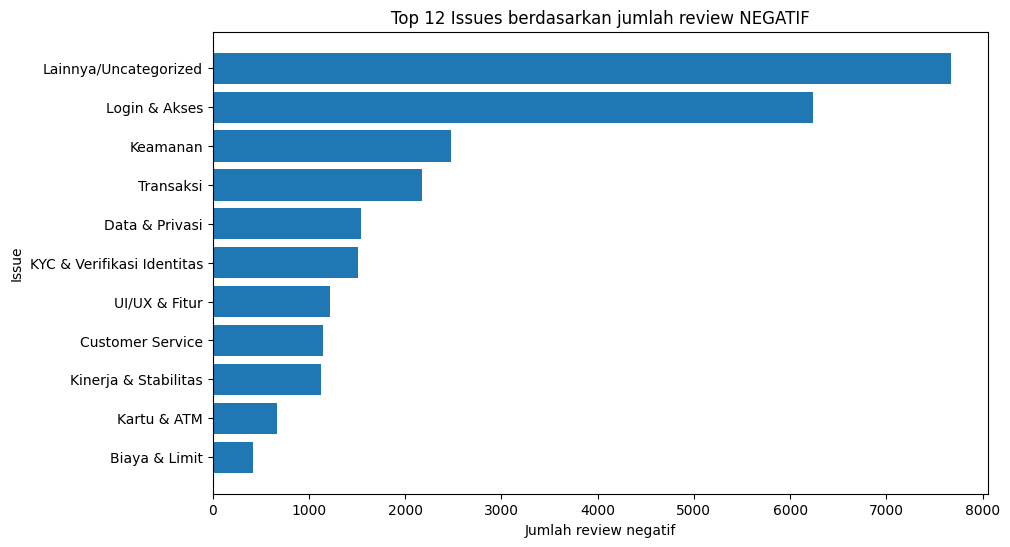

In [ ]:
top_n = 12
top_neg = summary.sort_values("negative", ascending=False).head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_neg.index[::-1], top_neg["negative"][::-1])
plt.title(f"Top {top_n} Issues berdasarkan jumlah review NEGATIF")
plt.xlabel("Jumlah review negatif")
plt.ylabel("Issue")
plt.show()

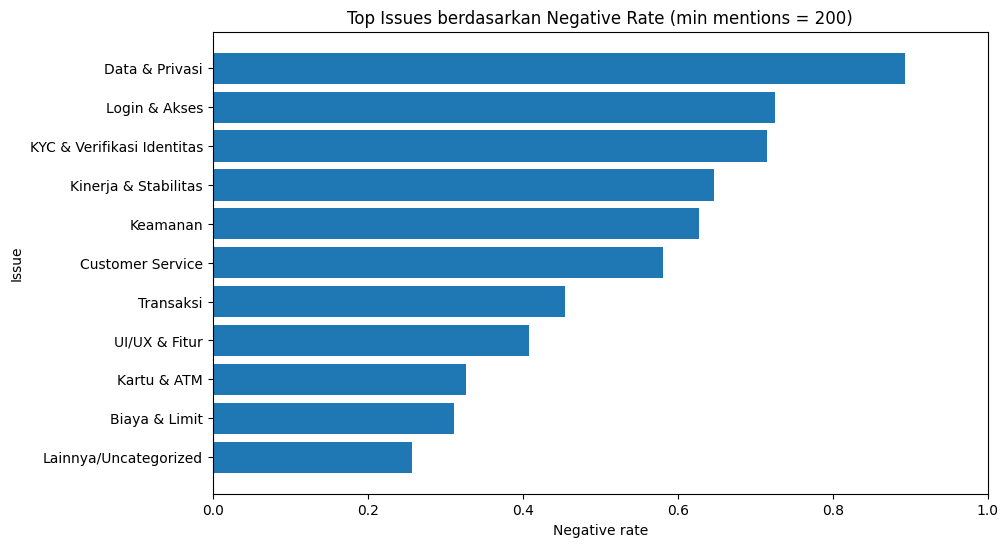

In [ ]:
min_mentions = 200
tmp = summary[summary["total_mentions"] >= min_mentions].copy()
top_rate = tmp.sort_values("neg_rate", ascending=False).head(12)

plt.figure(figsize=(10, 6))
plt.barh(top_rate.index[::-1], top_rate["neg_rate"][::-1])
plt.title(f"Top Issues berdasarkan Negative Rate (min mentions = {min_mentions})")
plt.xlabel("Negative rate")
plt.ylabel("Issue")
plt.xlim(0, 1)
plt.show()

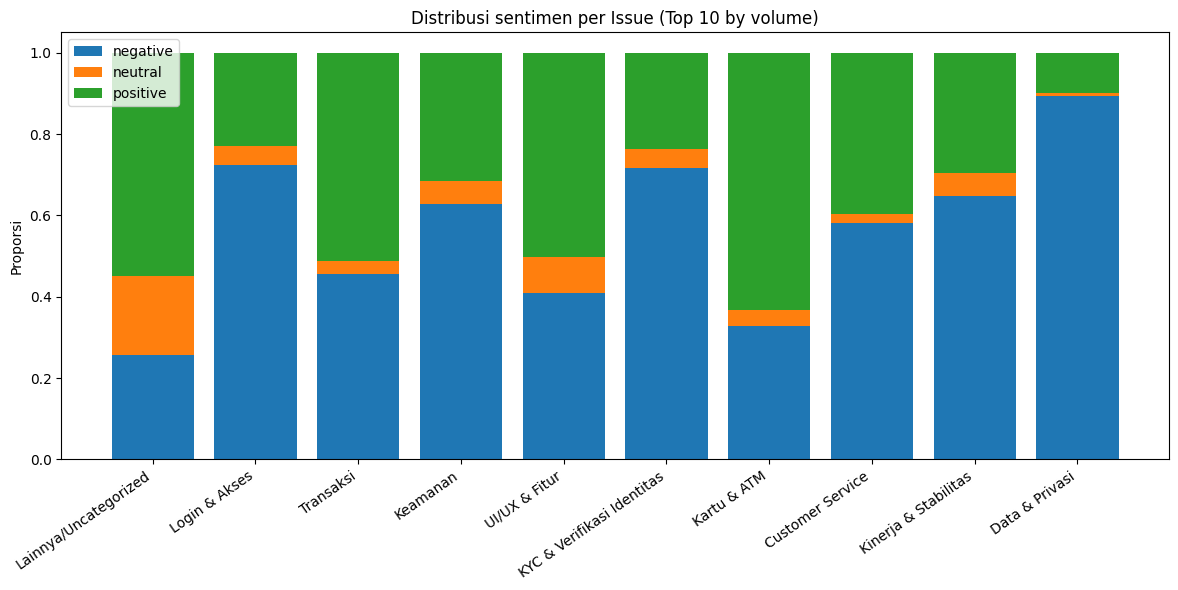

In [ ]:
top_n = 10
top_issues = summary.sort_values("total_mentions", ascending=False).head(top_n)

plot_df = top_issues[["negative","neutral","positive"]]
plot_df = plot_df.div(plot_df.sum(axis=1), axis=0)  # jadi proporsi (0-1)

plt.figure(figsize=(12, 6))
bottom = None
for col in ["negative", "neutral", "positive"]:
    if bottom is None:
        plt.bar(plot_df.index, plot_df[col], label=col)
        bottom = plot_df[col].values
    else:
        plt.bar(plot_df.index, plot_df[col], bottom=bottom, label=col)
        bottom = bottom + plot_df[col].values

plt.title(f"Distribusi sentimen per Issue (Top {top_n} by volume)")
plt.ylabel("Proporsi")
plt.xticks(rotation=35, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

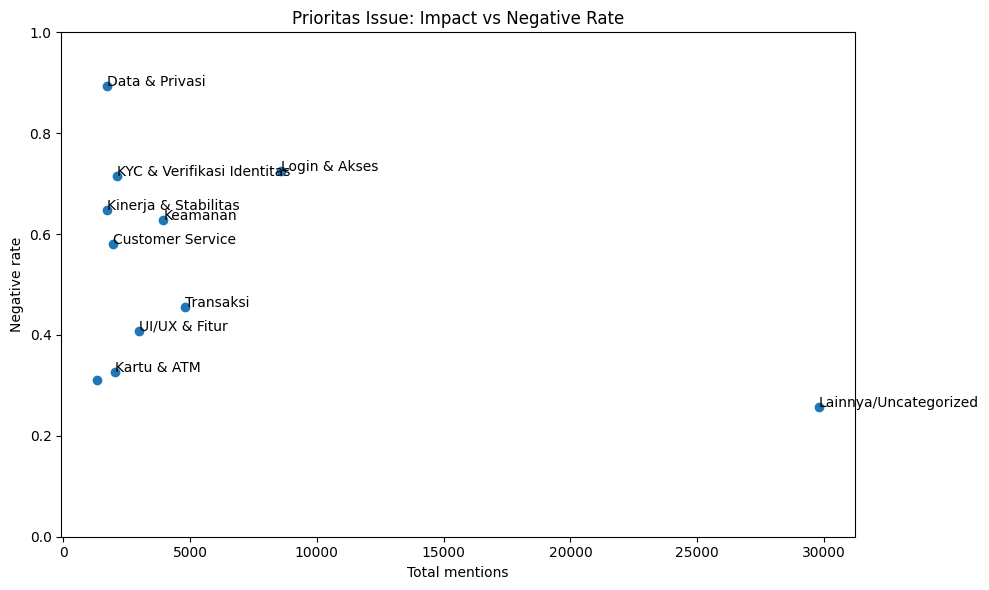

In [ ]:
min_mentions = 150
tmp = summary[summary["total_mentions"] >= min_mentions].copy()

x = tmp["total_mentions"]
y = tmp["neg_rate"]

plt.figure(figsize=(10, 6))
plt.scatter(x, y)

# label beberapa yang paling prioritas (misal score = x*y)
tmp["priority_score"] = tmp["total_mentions"] * tmp["neg_rate"]
label_df = tmp.sort_values("priority_score", ascending=False).head(10)

for issue, row in label_df.iterrows():
    plt.text(row["total_mentions"], row["neg_rate"], issue)

plt.title("Prioritas Issue: Impact vs Negative Rate")
plt.xlabel("Total mentions")
plt.ylabel("Negative rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

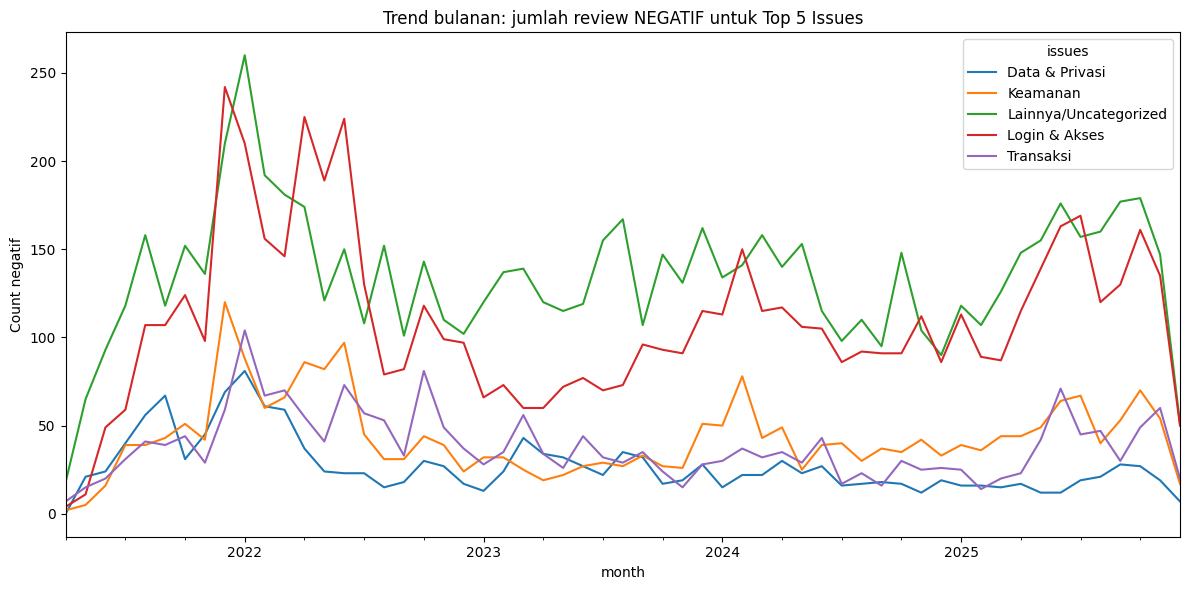

In [ ]:
df_time = df_issue.copy()
df_time = df_time[df_time["sent_pred"].isin(["negative","neutral","positive"])].copy()

# Convert 'review_at_raw' to datetime and create 'review_date'
df_time["review_date"] = pd.to_datetime(df_time["review_at_raw"])
df_time["month"] = df_time["review_date"].dt.to_period("M").dt.start_time

top5 = summary.sort_values("negative", ascending=False).head(5).index
neg_trend = (df_time[(df_time["issues"].isin(top5)) & (df_time["sent_pred"]=="negative")]
             .groupby(["month","issues"]).size().unstack(fill_value=0))

neg_trend.plot(figsize=(12,6))
plt.title("Trend bulanan: jumlah review NEGATIF untuk Top 5 Issues")
plt.xlabel("month")
plt.ylabel("Count negatif")
plt.tight_layout()
plt.show()